# 46500 part 2: introduction to Machine Learning - regression models
## 1 Introduction
This notebook provides an introduction to regression modelling using polynomials and simple ML methods.

We will go through a practical exercise, where the aim is characterizing the behaviour of the extreme loads at the root of a wind turbine blade and determining what is the dependence between these loads and environmental conditions (mean wind speed, turbulence, and wind shear). 
You are provided with a data set (ML_ExampleDataSet.xlsx) where 10-minute maxima for several wind turbine load channels are given as function of environmental conditions. 
Your main task is to:
-	Calibrate a regression model which maps the dependence between the loads and the environmental conditions. 
In addition, consider the following:
-	How would you evaluate the model performance?
-	What about trying different machine learning approaches – which one provides the best performance? 
-	For a particular choice of ML model, what hyperparameters provide the best performance, and how much data are necessary for achieving optimal performance?


Suggested procedure: <br>
1)	Load and parse input data; <br>
2)	Carry out explorative data analysis. Are there any visualisations which give a good overview of the data? Is any data filtering necessary?<br>
3)	Choose the type(s) of machine learning models you want to calibrate – what would an appropriate choice be, given the type of data you have, and given the required output?<br>
4)	Calibrate the surrogate model(s) of your choice<br>
5)	Make a residual analysis (plot residuals vs. variables) to check model adequacy, calculate error terms (e.g. r-square or RMS error) to evaluate the quality of the model fit and estimate model uncertainty <br>
6)	Explore changing hyperparameters and also running a convergence study – i.e., can we obtain a well-performing model with a fraction of the available data? <br>


## 2 Implementation

### 2.1 Data preparation

We will use a Pandas data frame which is a popular and efficient way of manipulating tabular data in Python.

In [1]:
import pandas as pd

In the cell below, enter code which loads the data from the sheet 'InputVariables' from the Excel file 'ML_ExampleDataSet.xlsx', and outputs a Pandas data frame called 'InputData'. Make sure the index of the 'InputData' frame is the 'Sample_No' column. Then you can display the first few rows of the dataframe using the DataFrame.head() command, where 'DataFrame' is replaced by the name of your dataframe object.

In [2]:
InputData = pd.read_excel('data/ML_ExampleDataSet.xlsx','InputVariables')
InputData = InputData.set_index('Sample_No',drop = False) # Make the "Sample_No" column as index of the data
InputData # Show the first few rows of the data

,Sample_No,U,SigmaU,Alpha,MannL,MannGamma,VeerDeltaPhi
Sample_No,,,,,,,
1,1,4.000000,0.100000,-0.650000,7.500000,1.000000,-22.250000
2,2,10.150758,1.208656,-0.139692,48.470634,1.363636,-4.771217
3,3,6.813467,2.261463,0.129071,88.379710,1.727273,-3.981593
4,4,14.500000,0.704260,0.332996,122.142857,2.090909,0.162810
5,5,5.356299,1.776301,1.147039,160.357143,2.454545,2.639008
...,...,...,...,...,...,...,...
9996,9996,15.991490,2.934493,-0.031461,271.543107,3.760740,14.080259
9997,9997,6.111425,0.948102,0.176589,8.454959,4.124377,41.866315
9998,9998,13.326172,2.043617,0.345013,46.669245,4.488013,-6.197441


In the cell below, enter code which loads the data from the sheet 'LoadResults' from the Excel file 'ML_ExampleDataSet.xlsx', and outputs a Pandas data frame called 'TargetData'. Make sure the index of the 'TargetData' frame is the 'PointNo' column.

In [3]:
TargetData = pd.read_excel('data/ML_ExampleDataSet.xlsx','LoadResults')
TargetData.set_index('PointNo', drop = False, inplace = True) # Make the "PointNo" column as index of the data
TargetData # Show the first few rows of the data

,PointNo,Tower_top_fore_aft_M_x,Tower_top_side2side_M_y,Tower_base_fore_aft_M_x,Tower_base_side2side_M_y,Yaw_moment_M_z,Main_shaft_torsion_M_z,Blade_root_flapwise_M_x,Blade_root_edgewise_M_y
PointNo,,,,,,,,,
1,1,747.561872,200.666288,6708.717789,8861.885588,1229.076579,63.457528,4253.317748,15006.726860
2,2,3556.031457,676.339081,16692.647572,6329.099515,6952.985180,1354.995442,10409.290476,16289.414152
3,3,4667.540374,1337.390736,47357.937376,31829.036012,10138.140146,2804.304402,13755.148891,16535.154243
4,4,2468.757942,242.431345,8130.594535,3871.907737,4216.051060,250.684887,12307.312889,16500.098901
5,5,3261.845253,1035.420007,36971.924749,26395.063750,6630.640795,2256.349794,13128.763279,16207.306417
...,...,...,...,...,...,...,...,...,...
9996,9996,6564.464434,858.778565,28091.651088,13608.101268,14513.682848,1147.107370,21518.552601,16773.394758
9997,9997,2047.344061,385.287048,22144.619831,16663.888804,3024.747490,676.705869,3891.227781,15376.750042
9998,9998,5958.074303,646.040924,20715.173212,7395.479028,11789.005321,740.922800,19334.780023,17384.510924


Now we have two data frames, which contain respectively the input variables and the dependent variables for our machine learning problem. However, we are not sure whether these are appropriately synchronized, i.e., whether the indexes of the two data frames match. Pandas provides several means of comparing data columns and merging data frames. One way of doing it is with the df.merge() command where df is the name of the data frame. Here we will use an "inner" merging, which means that only data entries which exist in both data frames to be merged, are being retained. In this way the merging also acts as a filter to eliminate entries where some of the data may not be available. In supervised machine learning, useful information is provided by from data entry pairs where both the input variables and the dependent variable are valid. If one finds it more convenient to keep the input feature and dependent variable data frames separate, a similar synchronization can be done by element-wise comparison of the data frames, using the df.where() command. The merge approach is slightly faster, as it requires fewer comparisons in the background.

The merge of the two dataframes is done in the cell below. 


In [4]:
AllInputData = InputData.where(InputData['Sample_No']==TargetData['PointNo'])
AllTargetData = TargetData.where(TargetData['PointNo']==InputData['Sample_No'])
AllInputData.drop(columns = 'Sample_No', inplace = True)
AllTargetData.drop(columns = 'PointNo', inplace = True)
nsamples = AllInputData['U'].count() # Find the total number of data points in the data frame
FeatureNames = AllInputData.columns.values
DependentVariableNames = AllTargetData.columns.values
print('Feature names: ', FeatureNames)
print('Dependent variable names: ', DependentVariableNames)
print(AllInputData.iloc[:,0].values)

Feature names:  ['U' 'SigmaU' 'Alpha' 'MannL' 'MannGamma' 'VeerDeltaPhi']
Dependent variable names:  ['Tower_top_fore_aft_M_x' 'Tower_top_side2side_M_y'
 'Tower_base_fore_aft_M_x' 'Tower_base_side2side_M_y' 'Yaw_moment_M_z'
 'Main_shaft_torsion_M_z' 'Blade_root_flapwise_M_x'
 'Blade_root_edgewise_M_y']
[ 4.         10.1507576   6.81346652 ... 13.32617204  9.2987816
 19.89821019]


In [5]:
AllInputData

,U,SigmaU,Alpha,MannL,MannGamma,VeerDeltaPhi
Sample_No,,,,,,
1,4.000000,0.100000,-0.650000,7.500000,1.000000,-22.250000
2,10.150758,1.208656,-0.139692,48.470634,1.363636,-4.771217
3,6.813467,2.261463,0.129071,88.379710,1.727273,-3.981593
4,14.500000,0.704260,0.332996,122.142857,2.090909,0.162810
5,5.356299,1.776301,1.147039,160.357143,2.454545,2.639008
...,...,...,...,...,...,...
9996,15.991490,2.934493,-0.031461,271.543107,3.760740,14.080259
9997,6.111425,0.948102,0.176589,8.454959,4.124377,41.866315
9998,13.326172,2.043617,0.345013,46.669245,4.488013,-6.197441


Let us visualize some of the features in the input data and the dependent variables. First, we'll make a scatter plot of the first 500 entries from the input variables. 

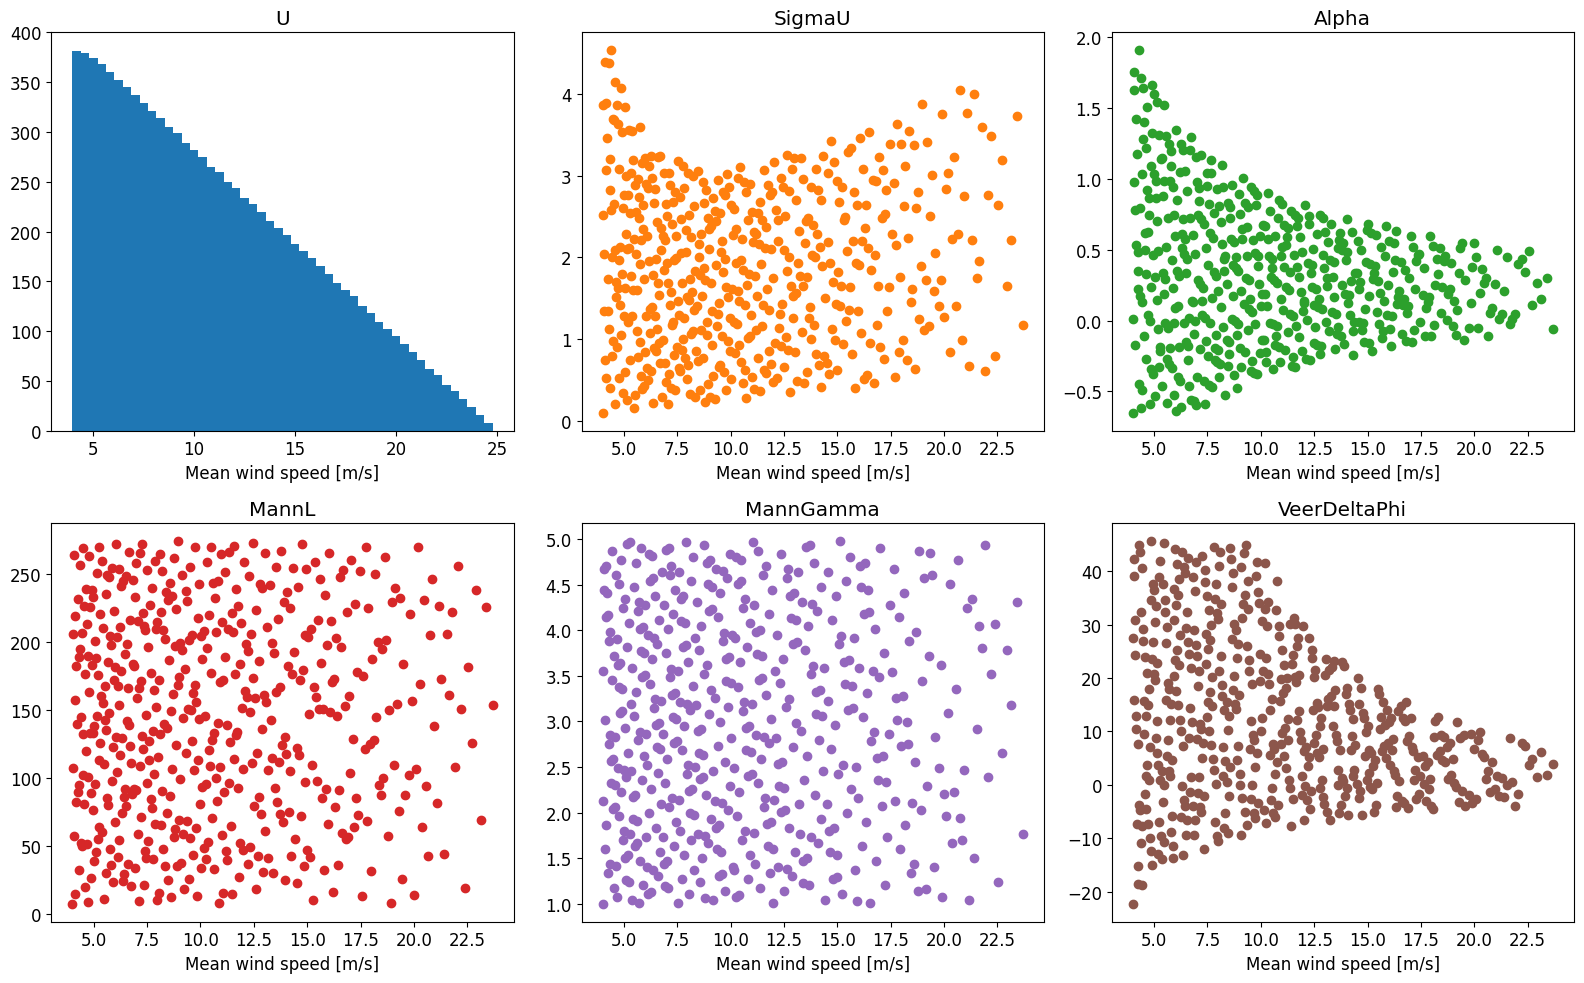

In [6]:
import matplotlib.pyplot as plt
nplotpoints = 500
plt.rc('font', size=12) 
fig1,axs1 = plt.subplots(2,3,figsize = (16,10))
plt.setp(axs1,xlabel = "Mean wind speed [m/s]")
plt.setp(axs1[0,0], title = FeatureNames[0])
plt.setp(axs1[0,1], title = FeatureNames[1])
plt.setp(axs1[0,2], title = FeatureNames[2])
plt.setp(axs1[1,0], title = FeatureNames[3])
plt.setp(axs1[1,1], title = FeatureNames[4])
plt.setp(axs1[1,2], title = FeatureNames[5])
axs1[0,0].hist(AllInputData.iloc[:,0],50,color = 'C0')
axs1[0,1].plot(AllInputData.iloc[0:nplotpoints,0],AllInputData.iloc[0:nplotpoints,1],'o',color = 'C1')
axs1[0,2].plot(AllInputData.iloc[0:nplotpoints,0],AllInputData.iloc[0:nplotpoints,2],'o',color = 'C2')
axs1[1,0].plot(AllInputData.iloc[0:nplotpoints,0],AllInputData.iloc[0:nplotpoints,3],'o',color = 'C3')
axs1[1,1].plot(AllInputData.iloc[0:nplotpoints,0],AllInputData.iloc[0:nplotpoints,4],'o',color = 'C4')
axs1[1,2].plot(AllInputData.iloc[0:nplotpoints,0],AllInputData.iloc[0:nplotpoints,5],'o',color = 'C5')
plt.tight_layout()             
plt.show()

#### Variable Descriptions 
* U: The histogram shows that wind speeds range approximately from 4 to 25 m/s. Lower and medium wind speeds occur more frequently than the highest wind speeds.

* SigmaU: Wind-speed variability is widely scattered, roughly between 0 and 4.5 m/s. There may be a slight increase in spread at higher U, but the relationship is weak.

* Alpha: There is a clear negative relationship with U. At low wind speeds, Alpha varies widely; as wind speed increases, its range becomes narrower and approaches zero.

* MannL: No obvious relationship with U. The values are broadly scattered across the wind-speed range.
MannGamma: Also shows little clear dependence on U; the points are distributed throughout the range.

* VeerDeltaPhi: Shows a noticeable negative relationship with U. Higher wind speeds generally correspond to lower values and a narrower spread.

#### Main conclusions of the graph

* Alpha and VeerDeltaPhi appear strongly dependent on mean wind speed and may be important predictors.
* SigmaU has a weaker relationship with wind speed but may show changing variability.
MannL and MannGamma do not show obvious relationships with U, although they may still influence the target variable through nonlinear or combined effects.
* The data are not described by simple linear relationships. Polynomial, tree-based, or neural-network models may therefore be more suitable.
* These plots show correlation only. They do not prove that a variable causes changes in another variable.
* The graph appears to use only the first 500 samples, so the conclusions should be checked using the complete dataset and with correlation or feature-importance analysis.

What is the relation between input variables and outputs? Since the wind speed is typically the most important variable, let us plot a few of the output variables as functions of the wind speed.

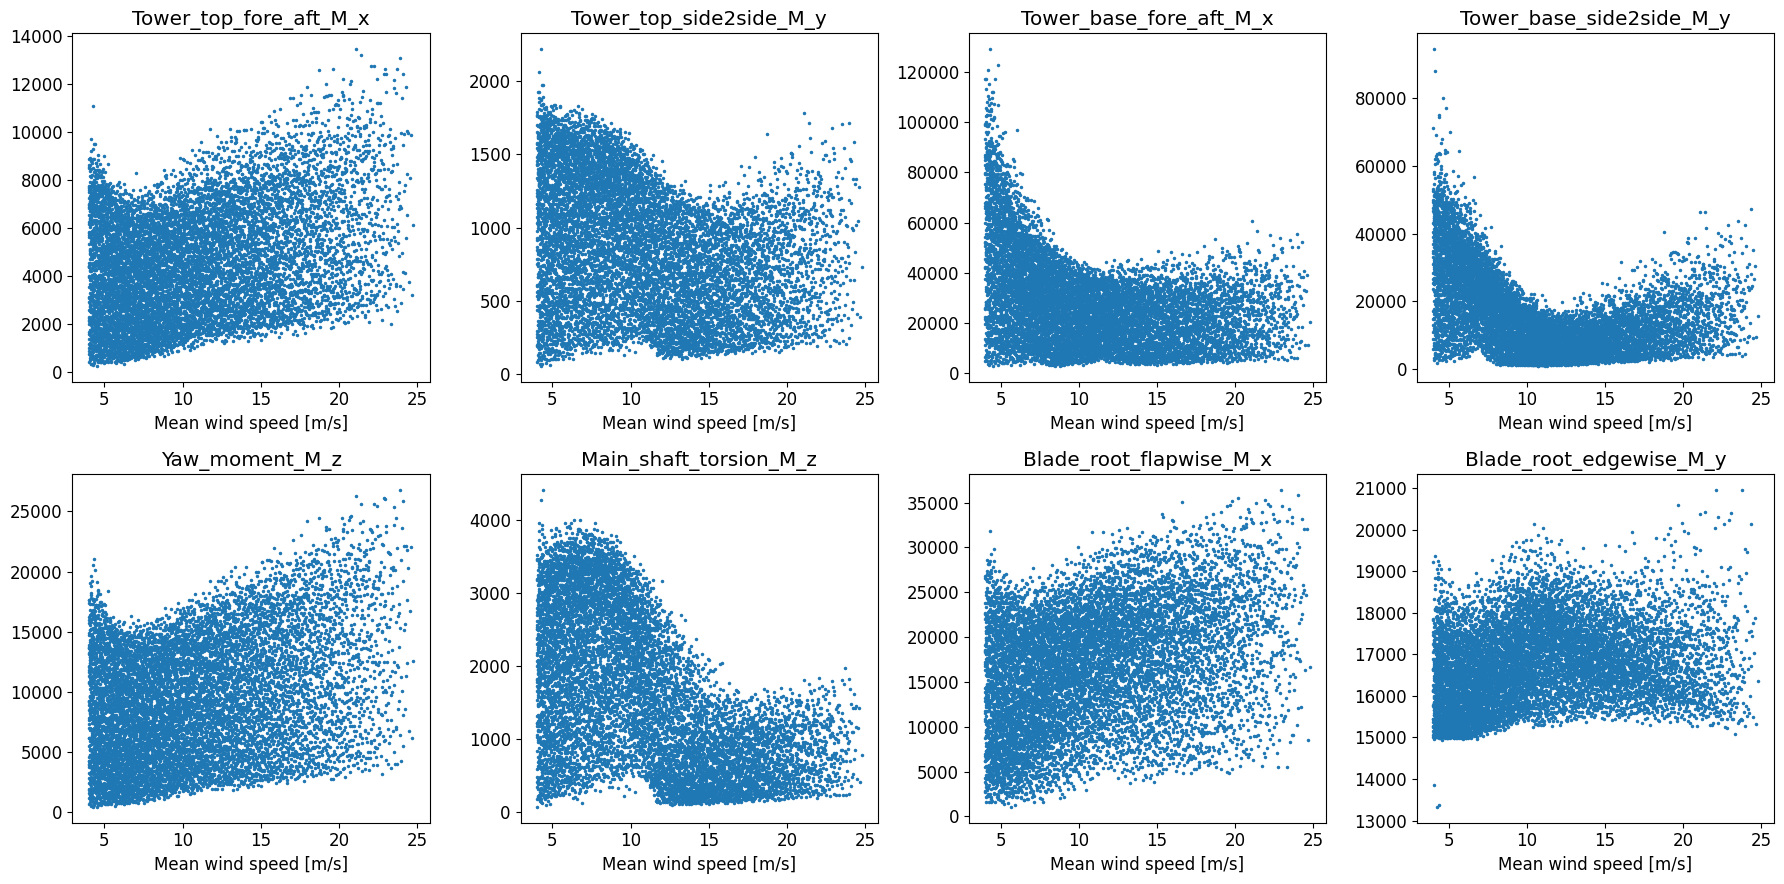

In [7]:
fig2 = plt.figure(2, figsize = (18,9))

for i in range(DependentVariableNames.shape[0]):
    axi = fig2.add_subplot(2,4,i+1)
    plt.title(DependentVariableNames[i])
    plt.plot(AllInputData.U,AllTargetData.iloc[:,i],'.',markersize = 3)
    plt.xlabel('Mean wind speed [m/s]')
    #plt.ylabel(DependentVariableNames[i])
plt.tight_layout()
plt.show()

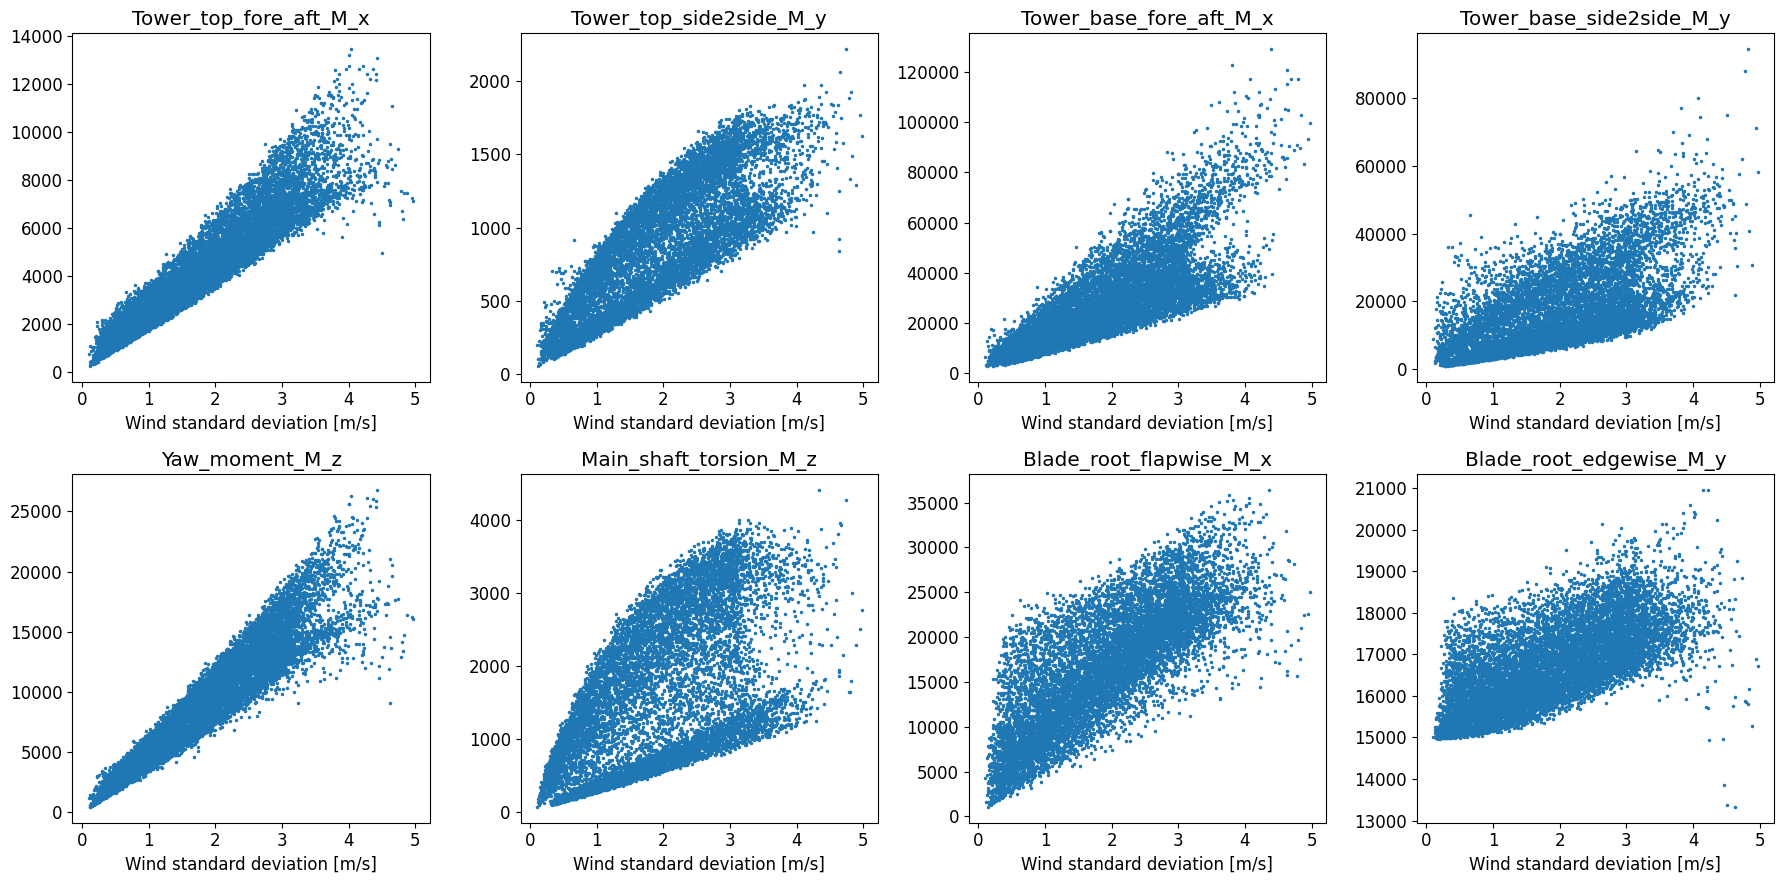

In [8]:
fig3 = plt.figure(3, figsize = (18,9))

for i in range(DependentVariableNames.shape[0]):
    axi = fig3.add_subplot(2,4,i+1)
    plt.title(DependentVariableNames[i])
    plt.plot(AllInputData.SigmaU,AllTargetData.iloc[:,i],'.',markersize = 3)
    plt.xlabel('Wind standard deviation [m/s]')
    #plt.ylabel(DependentVariableNames[i])
plt.tight_layout()
plt.show()

### 2.2 Fitting a polynomial model
Let us first try to fit a simple polynomial model of the type $y = ax_1^n + bx_1^{n-1} + \ldots + zx_m^n + \ldots$.

A model of this type can be represented in matrix form as:

$\mathbf{y} = \mathbf{X}{\beta}$

where $\mathbf{y}$ is a vector with outputs, $\boldsymbol{\beta}$ is a vector with the polynomial coefficients, and $\mathbf{X}$ is the design matrix containing combinations of input variables raised to various powers. The size of the design matrix is $[m,n]$ where $m$ is the number of data points to be predicted, and $n$ is the number of polynomial coefficients. 
The polynomial coefficients, $\boldsymbol{\beta}$, can be determined by considering pairs of measured (or simulated) inputs and outputs. For a sample of input data factored in a design matrix $\mathbf{X}$, and a corresponding set of outputs $\hat{\mathbf{y}}$, under certain conditions the polynomial coefficients $\boldsymbol{\beta}$ can be determined by a closed-form expression:

$\boldsymbol{\beta} = \left( \mathbf{X}^T \mathbf{X} \right)^{-1} \mathbf{X}^T\hat{\mathbf{y}}$

Note that the inversion is normally an inefficient operation in computing, that's why typically other algebraic methods are applied to solve an equation of the type $\mathbf{A}\mathbf{x} = \mathbf{b}$. Instead of computing $\mathbf{x} = inv(\mathbf{A})*\mathbf{b}$, we can in python use the command *x = np.linalg.lstsq(A,b)*

Another hint: matrix multiplication with python can be easily done using the *np.dot()* command, for example computing $\mathbf{A}*\mathbf{B}$ could be done with *np.dot(A,B)*

In [10]:
# Building a design matrix for a polynomial of 3rd order
def DesignMatrixO3(X):
    ndim = X.shape[1] 
    npoints = X.shape[0]
    m = int(((ndim-1)/2)*ndim)
    Xmatrix = np.zeros((npoints,3*ndim + 3*m + 1))
    columncount = 0
    Xmatrix[:,columncount] = np.ones(npoints)
    for i in range(ndim):
        columncount+=1
        Xmatrix[:,columncount] = X[:,i]

    for i in range(ndim -1):
        for j in range(i+1,ndim):
            columncount+= 1
            Xmatrix[:,columncount] = X[:,i]*X[:,j]

    for i in range(ndim):
        columncount+= 1
        Xmatrix[:,columncount] = X[:,i]**2

    for i in range(ndim-1):
        for j in range(i+1,ndim):
            columncount+= 1
            Xmatrix[:,columncount] = (X[:,i]**2)*X[:,j]

    for i in range(ndim-1):
        for j in range(i+1,ndim):
            columncount+= 1
            Xmatrix[:,columncount] = X[:,i]*(X[:,j]**2)

    for i in range(ndim):
        columncount+=1
        Xmatrix[:,columncount] = X[:,i]**3
    return Xmatrix


def PredictPolyO3(X,Alsq):
    Xmatrix = DesignMatrixO3(X)
    Y = np.dot(Xmatrix,Alsq)
    return Y

In [11]:
AllInputData.values

array([[ 4.00000000e+00,  1.00000000e-01, -6.50000000e-01,
         7.50000000e+00,  1.00000000e+00, -2.22500000e+01],
       [ 1.01507576e+01,  1.20865642e+00, -1.39691519e-01,
         4.84706339e+01,  1.36363636e+00, -4.77121702e+00],
       [ 6.81346652e+00,  2.26146310e+00,  1.29071159e-01,
         8.83797099e+01,  1.72727273e+00, -3.98159257e+00],
       ...,
       [ 1.33261720e+01,  2.04361659e+00,  3.45013069e-01,
         4.66692450e+01,  4.48801311e+00, -6.19744103e+00],
       [ 9.29878160e+00,  2.83002980e+00,  7.09374276e-01,
         8.48835307e+01,  4.85164948e+00, -4.45739239e+00],
       [ 1.98982102e+01,  6.84805058e-01,  5.74861537e-01,
         1.23097816e+02,  1.24834369e+00, -1.81735203e+00]],
      shape=(9980, 6))

In [13]:
# MAKE A 3-RD ORDER POLYNOMIAL FIT TO THE DATA USING THE HELPER FUNCTIONS GIVEN ABOVE
import numpy as np
Y1 = AllTargetData['Tower_base_fore_aft_M_x']
X = AllInputData.values

# Create the design matrix for a 3rd order polynomial
Xmatrix = DesignMatrixO3(X)

XX = np.dot(Xmatrix.T, Xmatrix)     
XY = np.dot(Xmatrix.T, Y1)
Alsq = np.linalg.solve(XX, XY)
Alsq.shape

Ypred_O3 = np.dot(Xmatrix, Alsq)

In [16]:
Ypred_O3

array([ 7038.20836404, 17951.4546767 , 45017.14488093, ...,
       22318.37992223, 42636.14491582, 11029.64742859], shape=(9980,))

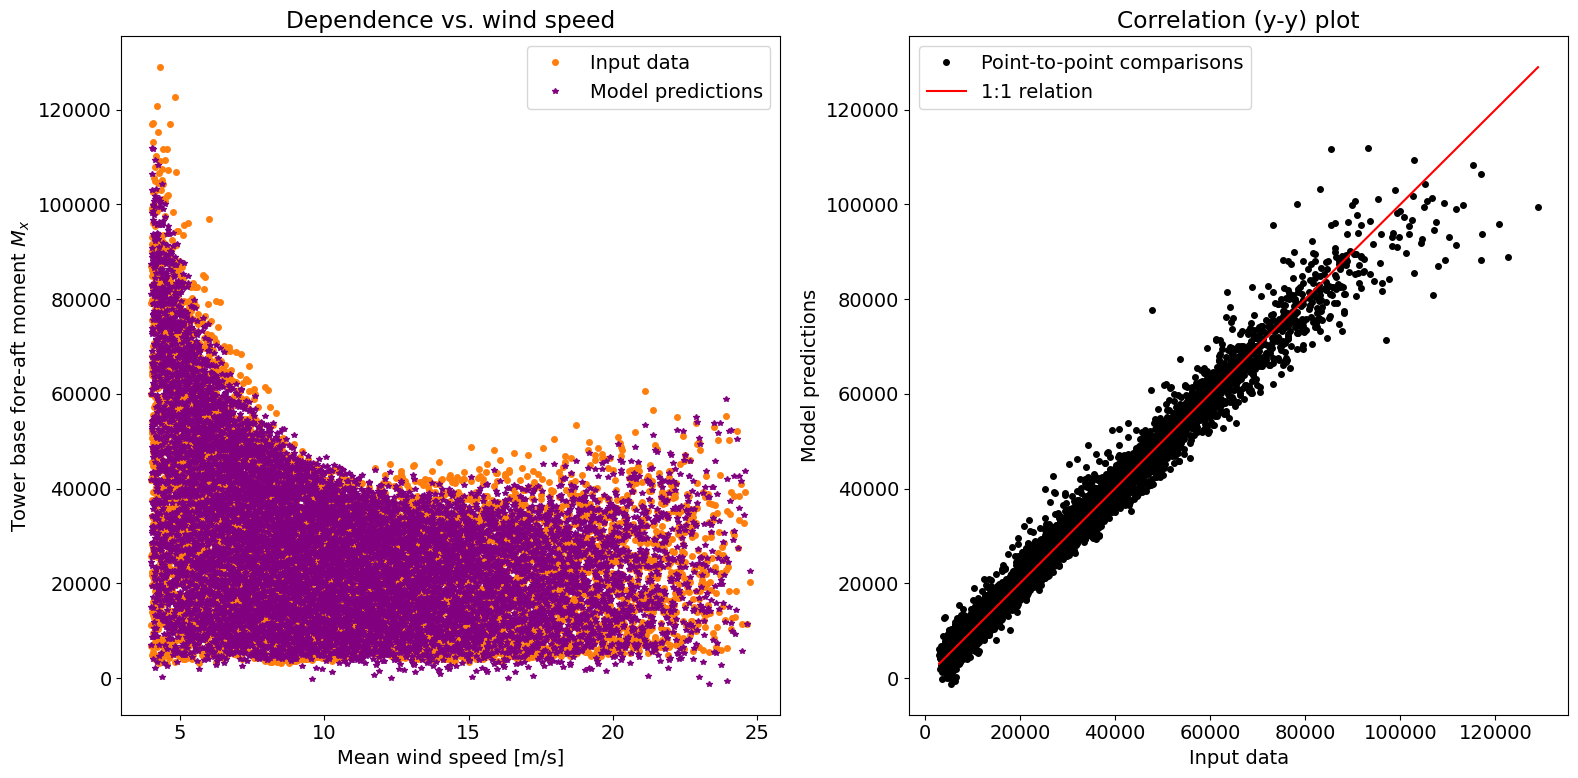

In [17]:
# VISUALISE RESULTS FROM THE PREDICTION
plt.rc('font', size=14) 
fig2a,axs2a = plt.subplots(1,2,figsize = (16,8))
plt.setp(axs2a[0], title = 'Dependence vs. wind speed', xlabel = 'Mean wind speed [m/s]',ylabel = 'Tower base fore-aft moment $M_x$')
plt.setp(axs2a[1], title = 'Correlation (y-y) plot', xlabel = 'Input data',ylabel = 'Model predictions')
axs2a[0].plot(AllInputData['U'],AllTargetData['Tower_base_fore_aft_M_x'],'o',markersize = 4,color = 'C1')
axs2a[0].plot(AllInputData['U'],Ypred_O3,'*',markersize = 4,color = 'purple')
axs2a[0].legend(['Input data','Model predictions'])
axs2a[1].plot(AllTargetData['Tower_base_fore_aft_M_x'],Ypred_O3,'ok',markersize = 4)
axs2a[1].plot(np.array([np.min(AllTargetData['Tower_base_fore_aft_M_x']), np.max(AllTargetData['Tower_base_fore_aft_M_x'])]),\
             np.array([np.min(AllTargetData['Tower_base_fore_aft_M_x']), np.max(AllTargetData['Tower_base_fore_aft_M_x'])]),'-r')
axs2a[1].legend(['Point-to-point comparisons','1:1 relation'])
plt.tight_layout()             
plt.show()

#### Model performance assessment
Now we have trained a simple ML (regression) model. The plots are one way to assess its performance, but we normally want quantitative comparisons too. In our slides, we have listed a couple of popular measures of regression model performance - including R-squared, RMSE, and MAE. Let us compute these below (and also repeat the computation for any other model we train).

The formulas are:

$r^2 = 1 - \left(\frac{\sum_i{(y_i - g(x_i))^2}}{\sum_i{(y_i - \bar{y})^2}} \right)$

$RMSE = \sqrt{MSE} = \sqrt{\mathbb{E}\left( (y - g(x))^2\right)} = \sqrt{\frac{\sum_i{\left(y_i - g(x_i)\right)^2}}{N}}$

$MAE = \sum_{i=1}^N{\frac{|y_i - g(x_i)|}{N}}$

Interestingly, for well-performing models, the R-squared is approximately equal to the correlation coefficient between the target data and the model predictions. 

In [18]:
Rsq_poly = 1 - np.sum( (Y1 - Ypred_O3)**2) / np.sum((Y1 - np.mean(Y1))**2)
Rsq_corr_poly = (np.corrcoef(Y1,Ypred_O3)[0,1])**2 # R-squared with the correlation coefficient
RMSE_poly = np.sqrt( np.mean((Y1 - Ypred_O3)**2))
print('R-square of polynomial model: ' + str(Rsq_poly))
print('R-square computed through correlations: ' + str(Rsq_corr_poly))
print('RMSE of polynomial model: ' + str(RMSE_poly))

R-square of polynomial model: 0.978993405380794
R-square computed through correlations: 0.9789934053807946
RMSE of polynomial model: 2572.9474218402283


In [19]:
epsilon = Y1 - Ypred_O3
bias = np.mean(epsilon)
variance = np.var(epsilon)
print('Bias of polynomial model: ' + str(bias))
print('Variance of polynomial model: ' + str(variance))

Bias of polynomial model: -7.849650103822799e-11
Variance of polynomial model: 6620058.435554279


### 2.3. Fitting a Random Forest model

Random forest (RF) is a popular Machine Learning method. Its popularity is due to the simplicity (very few hyperparameters) and good performance on simple modelling tasks. 
As discussed in the accompanying slides, Random Forest is essentially a combination of decision trees where the output of each tree is determined by "branching" conditions (logical "<" and ">"). The tree-based algorithm natively belongs to the family of discrete models (why? can you discuss?) - with some adaptations making it capable of approximating continuous functions. The discrete origin of the RF model may pose some challenges for using RF-based "surrogate models" for optimization. Could you think why this may be the case?

In [20]:
import sklearn
RFregressor = sklearn.ensemble.RandomForestRegressor(n_estimators = 100)
RFregressor.fit(X,Y1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
Yout = RFregressor.predict(X)
RFregressor.score(X,Y1)

0.9980125128862741

In [27]:
Bias_RF = np.mean(Y1 - Yout)
RMSE_RF = np.sqrt(np.mean((Y1 - Yout)**2))

print('RMSE of random forest model: ' + str(RMSE_RF))
print('Bias of random forest model: ' + str(Bias_RF))

RMSE of random forest model: 791.4167632354207
Bias of random forest model: -7.421655400786495


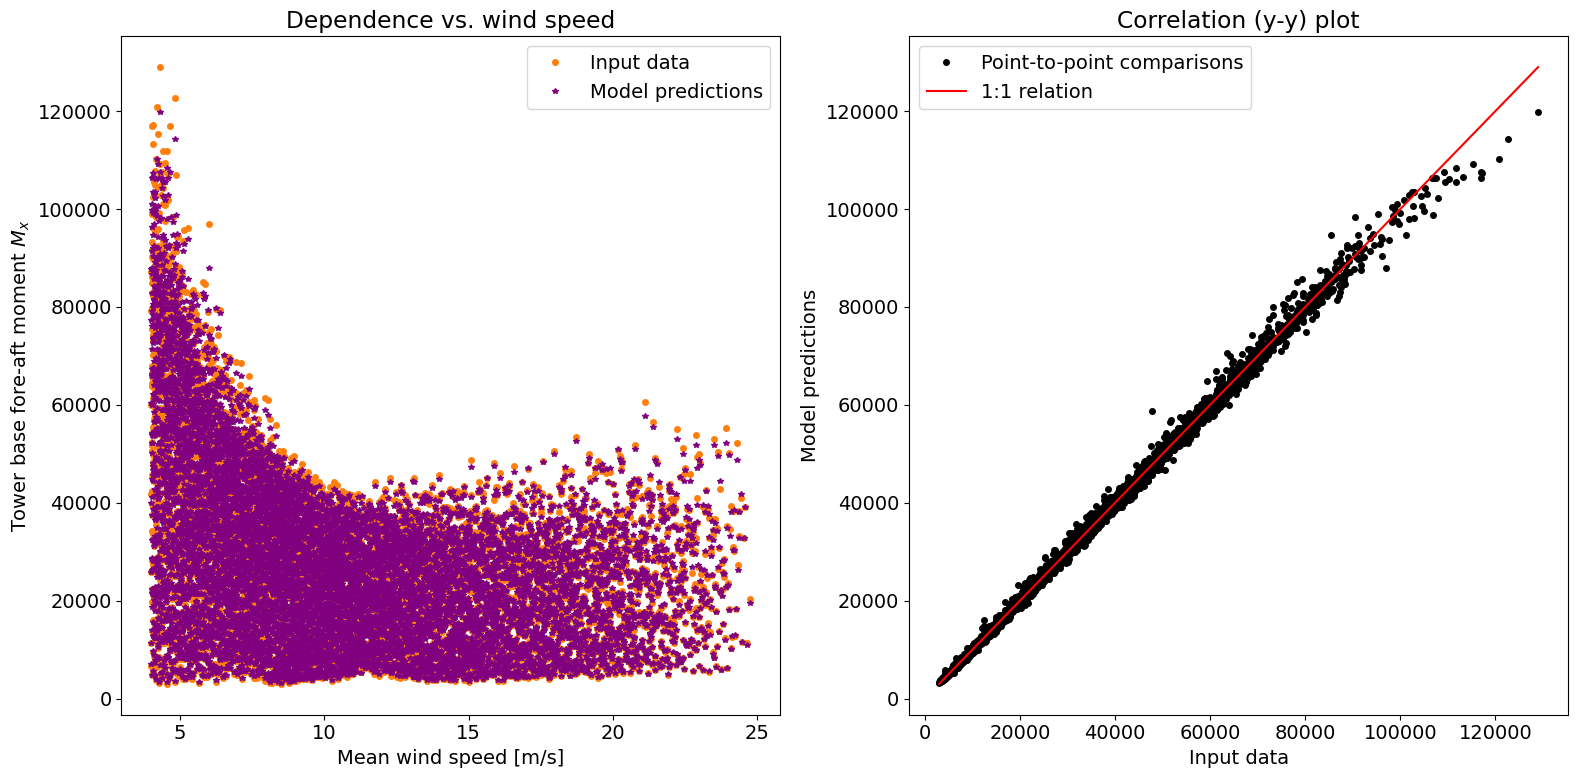

In [28]:
# VISUALISE RESULTS FROM THE PREDICTION
plt.rc('font', size=14) 
fig2b,axs2b = plt.subplots(1,2,figsize = (16,8))
plt.setp(axs2b[0], title = 'Dependence vs. wind speed', xlabel = 'Mean wind speed [m/s]',ylabel = 'Tower base fore-aft moment $M_x$')
plt.setp(axs2b[1], title = 'Correlation (y-y) plot', xlabel = 'Input data',ylabel = 'Model predictions')
axs2b[0].plot(AllInputData['U'],AllTargetData['Tower_base_fore_aft_M_x'],'o',markersize = 4,color = 'C1')
axs2b[0].plot(AllInputData['U'],Yout,'*',markersize = 4,color = 'purple')
axs2b[0].legend(['Input data','Model predictions'])
axs2b[1].plot(AllTargetData['Tower_base_fore_aft_M_x'],Yout,'ok',markersize = 4)
axs2b[1].plot(np.array([np.min(AllTargetData['Tower_base_fore_aft_M_x']), np.max(AllTargetData['Tower_base_fore_aft_M_x'])]),\
             np.array([np.min(AllTargetData['Tower_base_fore_aft_M_x']), np.max(AllTargetData['Tower_base_fore_aft_M_x'])]),'-r')
axs2b[1].legend(['Point-to-point comparisons','1:1 relation'])
plt.tight_layout()             
plt.show()

#### Question:
 Was the above the best practice approach of fitting and testing ML models? What else do we need to consider when testing the performance?

### 2.4 Fitting an Artificial Neural Network model

In [29]:
import sklearn
import sklearn.neural_network

In the cell below, we will start using the scikit-learn toolbox which provides possibilities for fitting Artificial Neural Network models. Let us start with defining a regression model (*sklearn.neural_network.MLPRegressor*) - using a hyperbolic tangent activation function, and with two hidden layers with 12 perceptrons each. Then we can also play with other hyperparameters: batch size, initial learning rate, and other.

In [30]:
# SKLEARN Neural Network MLP regressor model
ANNmodel = sklearn.neural_network.MLPRegressor()
ANNmodel.get_params()

{'activation': 'relu',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (100,),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'loss': 'squared_error',
 'max_fun': 15000,
 'max_iter': 200,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

Let us try to quickly fit a model with activation = tanh, and hidden layer size 10 (fill in the spaces in the cell below). 

In [35]:
# BEGIN CODE HERE
ANNmodel.set_params(activation = 'tanh', hidden_layer_sizes = (10, 10))

# END CODE HERE

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [ ]:
ANNmodel.score(AllInputData,Y1)

Does the model with tanh activation converge? Let us also try with a relu activation:

In [ ]:
# BEGIN CODE HERE
ANNmodel.set_params()

# END CODE HERE
print('Model r-square with full data set: ' + str(ANNmodel.score(AllInputData,AllTargetData['Tower_base_fore_aft_M_x'])))

In [ ]:
ANNmodel.score(AllInputData,Y1)

If one or more of the above fits did not work, what is the possible reason?
Now let us try to tweak our data a bit and make it better suitable for our ML model. In the cell below, try to normalize both the input and output data using the *sklearn.preprocessing.StandardScaler()* method:

In [36]:

#X = (AllInputData - AllInputData.mean(axis=0))/AllInputData.std(axis=0)

Xscaler = sklearn.preprocessing.StandardScaler()
Yscaler = sklearn.preprocessing.StandardScaler()

# BEGIN CODE HERE
Xscaler = Xscaler.fit(AllInputData.values)
Yscaler = Yscaler.fit(AllTargetData['Tower_base_fore_aft_M_x'].values.reshape(-1,1))

TrainTestRatio = 0.8
N = len(AllInputData)
Xtrain = AllInputData.values[0:int(N*TrainTestRatio),:]
Xtest = AllInputData.values[int(N*TrainTestRatio):,:]

Ytrain = Yscaler.transform(AllTargetData['Tower_base_fore_aft_M_x'].values.reshape(-1,1))[0:int(N*TrainTestRatio),:]
Ytest = Yscaler.transform(AllTargetData['Tower_base_fore_aft_M_x'].values.reshape(-1,1))[int(N*TrainTestRatio):,:]

# END CODE HERE

# UNCOMMENT TO REPLACE THE ABOVE CODE WITH A VERSION THAT USES ALL DATA FOR TRAINING
#Xtrain = Xscaler.transform(AllInputData.values)
#Ytrain = Yscaler.transform(AllTargetData['Tower_base_fore_aft_M_x'].values.reshape(-1,1))
#Xtest = Xtrain
#Ytest = Ytrain





In [37]:
Xtest.shape

(1996, 6)

Now, let us make a fit using the transformed data:

In [38]:
ANNmodel.set_params(learning_rate_init = 0.01, activation = 'relu',tol = 1e-6,n_iter_no_change = 10, hidden_layer_sizes = (12,12), validation_fraction = 0.1)
# BEGIN CODE HERE
ANNmodel.fit(Xtrain, Ytrain)
# END CODE HERE

c:\Users\natal\repos\OceanCourses\.ocean\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1775: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(12, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [42]:
print( 'Train set r-square: ' + str(ANNmodel.score(Xtrain,Ytrain)))
print( 'Test set r-square: ' + str(ANNmodel.score(Xtest,Ytest)))

Train set r-square: 0.9646105811969127
Test set r-square: 0.9634637528220895


In [40]:
# COMPUTE MODEL PREDICTIONS FOR ALL TEST DATA:
# BEGIN CODE HERE
Yout = Yscaler.inverse_transform(ANNmodel.predict(Xtrain).reshape(-1, 1))
Yout_test = Yscaler.inverse_transform(ANNmodel.predict(Xtest).reshape(-1, 1))
# END CODE HERE

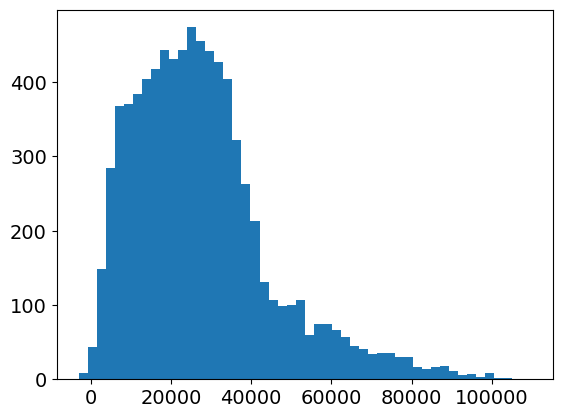

In [41]:
plt.hist(Yout,50)
plt.show()

Let us compare the model predictions with the target data:

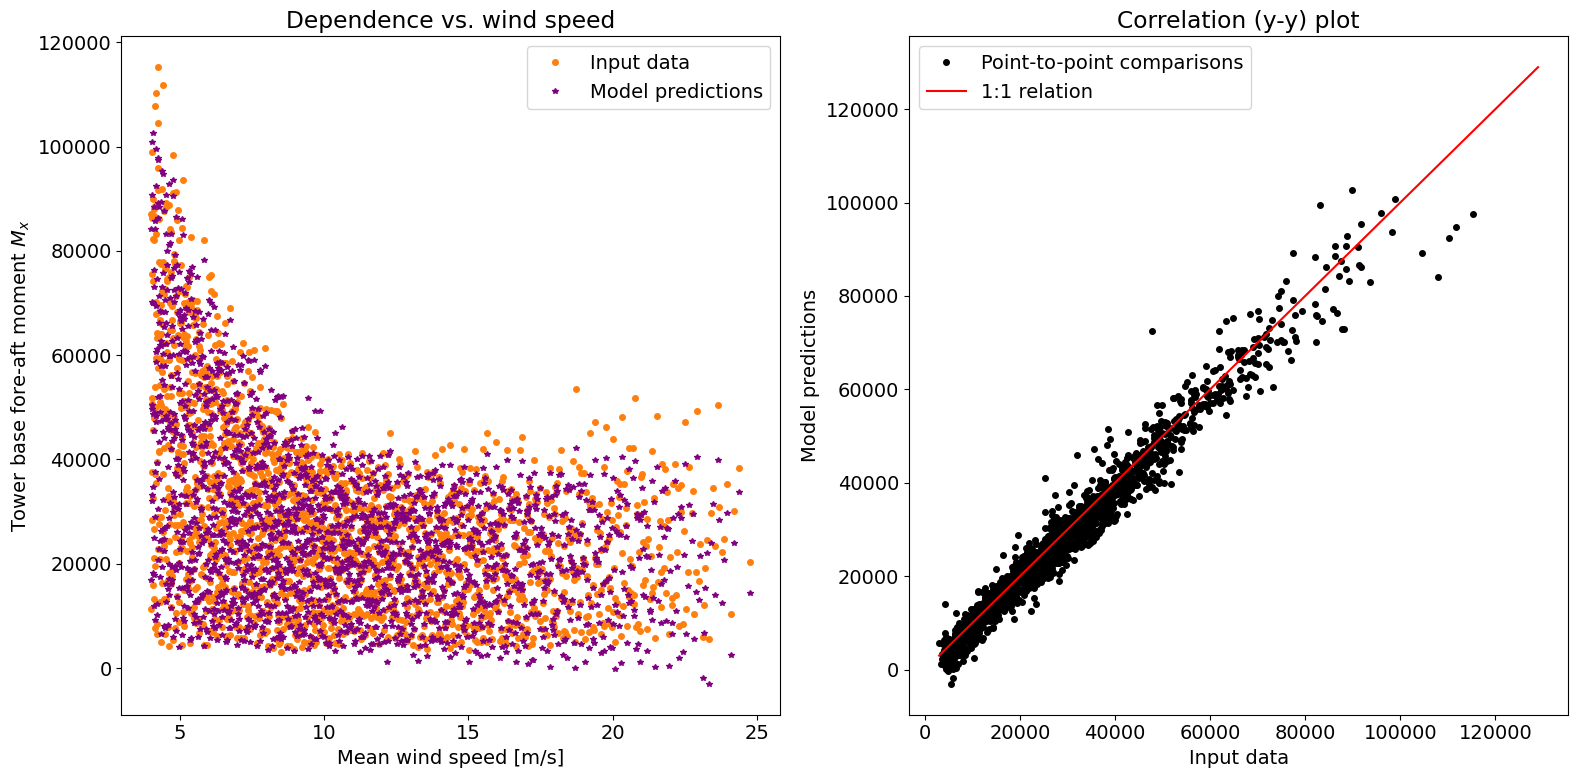

In [43]:
import numpy as np
plt.rc('font', size=14) 
fig3,axs3 = plt.subplots(1,2,figsize = (16,8))
plt.setp(axs3[0], title = 'Dependence vs. wind speed', xlabel = 'Mean wind speed [m/s]',ylabel = 'Tower base fore-aft moment $M_x$')
plt.setp(axs3[1], title = 'Correlation (y-y) plot', xlabel = 'Input data',ylabel = 'Model predictions')
axs3[0].plot(Xtest[:,0],Yscaler.inverse_transform(Ytest),'o',markersize = 4,color = 'C1')
axs3[0].plot(Xtest[:,0],Yout_test,'*',markersize = 4,color = 'purple')
axs3[0].legend(['Input data','Model predictions'])
axs3[1].plot(Yscaler.inverse_transform(Ytest),Yout_test,'ok',markersize = 4)
axs3[1].plot(np.array([np.min(AllTargetData['Tower_base_fore_aft_M_x']), np.max(AllTargetData['Tower_base_fore_aft_M_x'])]),\
             np.array([np.min(AllTargetData['Tower_base_fore_aft_M_x']), np.max(AllTargetData['Tower_base_fore_aft_M_x'])]),'-r')
axs3[1].legend(['Point-to-point comparisons','1:1 relation'])
plt.tight_layout()             
plt.show()

In [ ]:
plt.plot(Yout_test,Yscaler.inverse_transform(Ytest)/Yout_test, 'xk')